# Tutorial for `DTM` Module

A document-term matrix (DTM) is the standard interface for analysis and information of document data, consisting of a list of term (unique token) counts per document arranged as a matrix. In many real-world text collections, most documents only contain a small fraction of all possible terms, resulting in a sparse matrix where the majority of values are zero—this allows for highly efficient storage and processing. The DTM is fundamental in text analysis because it transforms a collection of documents into a structured, numerical format suitable for computational analysis, enabling a wide range of analyses such as identifying common terms, comparing document similarity, and serving as input for machine learning models. By quantifying textual data, the DTM makes it possible to apply statistical and algorithmic techniques to extract insights from text. 

In this tutorial, we will understand what is a Document-Term Matrix, its applications, and what the `dtm` module can achieve, as we go through the process of using real texts to create our own DTM, and explore what can be be done with it.

## Preparing Your Documents

A document-term matrix is constructed by counting tokens to calculate the number of unique token forms -- or terms -- per document. This procedure requires the input documents to be already tokenised. To illustrate, we'll use a toy dataset consisting of the first sentence in each of three novels.

In [ ]:
toy_data = {
    "Metamorphosis": "One morning, when Gregor Samsa woke from troubled dreams, he found himself transformed in his bed into a horrible vermin.",
    "Jekyll_and_Hyde": "Mr. Utterson the lawyer was a man of a rugged countenance that was never lighted by a smile; cold, scanty and embarrassed in discourse; backward in sentiment; lean, long, dusty, dreary and yet somehow lovable.",
    "Alice_in_Wonderland": "Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, “and what is the use of a book,” thought Alice “without pictures or conversations?”",
}

# Get a list of labels and texts from the toy dataset
labels = list(toy_data.keys())
texts = list(toy_data.values())

# Import the Lexos Tokenizer class
from lexos.tokenizer import Tokenizer

# Tokenize the texts
tokenizer = Tokenizer(model="en_core_web_sm")
docs = tokenizer.make_docs(texts)

# Create lists of doc tokens, removing spaces, punctuation, and digits
doc_tokens = []
for doc in docs:
    tokens = [token.text for token in doc if not (token.is_space or token.is_punct or token.is_digit)]
    doc_tokens.append(tokens)

# Print the cleaned documents with their labels
for i, doc in enumerate(doc_tokens):
    print(f"{labels[i]}:")
    print(f"{doc}\n")
print(labels)

We're now ready to build a DTM.

In [ ]:
# Import the DTM class
from lexos.dtm import DTM

# labels = ["Metamorphosis", "Jekyll_and_Hyde", "Alice_in_Wonderland"]
# doc_tokens = [['One', 'morning', 'when', 'Gregor', 'Samsa', 'woke', 'from', 'troubled', 'dreams', 'he', 'found', 'himself', 'transformed', 'in', 'his', 'bed', 'into', 'a', 'horrible', 'vermin'], ['Mr.', 'Utterson', 'the', 'lawyer', 'was', 'a', 'man', 'of', 'a', 'rugged', 'countenance', 'that', 'was', 'never', 'lighted', 'by', 'a', 'smile', 'cold', 'scanty', 'and', 'embarrassed', 'in', 'discourse', 'backward', 'in', 'sentiment', 'lean', 'long', 'dusty', 'dreary', 'and', 'yet', 'somehow', 'lovable'], ['Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to', 'do', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into', 'the', 'book', 'her', 'sister', 'was', 'reading', 'but', 'it', 'had', 'no', 'pictures', 'or', 'conversations', 'in', 'it', 'and', 'what', 'is', 'the', 'use', 'of', 'a', 'book', 'thought', 'Alice', 'without', 'pictures', 'or', 'conversations']]

# Initialize the DTM model
dtm = DTM() # vts are converted to a mapping
# Build the DTM using the cleaned documents and labels
dtm(doc_tokens, labels)

# Print the shape of the document-term matrix
print(dtm.shape)
print(f"{dtm.shape[0]} rows (docs), {dtm.shape[1]} columns (terms)")

(3, 80)
3 rows (docs), 80 columns (terms)


*Voilà*! We now have a DTM. By default, `DTM` creates a document-term matrix where each column represents a single term and each cell contains the **raw count** of how many times that terms appears in the document.

The output of `dtm.shape` shows us that we now have a matrix with the columns, corresponding to our 3 documents, and 80 rows, corresponding to the 80 unique terms found in the collection.

If we wish to see the terms, we can call `dtm.sorted_terms_list`.

In [4]:
print(f"**List of Terms:**\n{dtm.sorted_terms_list}")

**List of Terms:**
['a', 'and', 'Alice', 'backward', 'bank', 'bed', 'beginning', 'book', 'but', 'by', 'cold', 'conversations', 'countenance', 'discourse', 'do', 'dreams', 'dreary', 'dusty', 'embarrassed', 'found', 'from', 'get', 'Gregor', 'had', 'having', 'he', 'her', 'himself', 'his', 'horrible', 'in', 'into', 'is', 'it', 'lawyer', 'lean', 'lighted', 'long', 'lovable', 'man', 'morning', 'Mr.', 'never', 'no', 'nothing', 'of', 'on', 'once', 'or', 'One', 'peeped', 'pictures', 'reading', 'rugged', 'scanty', 'sentiment', 'she', 'sister', 'sitting', 'smile', 'somehow', 'Samsa', 'that', 'the', 'thought', 'tired', 'to', 'transformed', 'troubled', 'twice', 'use', 'Utterson', 'vermin', 'very', 'was', 'what', 'when', 'without', 'woke', 'yet']


This terms list is also known as the **vocabulary**. If we wish to see the counts for each item in the vocabulary, we can call `dtm.sorted_term_counts`.

In [5]:
print("**Term Counts:**")
for k, v in dtm.sorted_term_counts.items():
    print(f"{k}: {v}")

**Term Counts:**
a: 5
and: 4
Alice: 2
backward: 1
bank: 1
bed: 1
beginning: 1
book: 2
but: 1
by: 2
cold: 1
conversations: 2
countenance: 1
discourse: 1
do: 1
dreams: 1
dreary: 1
dusty: 1
embarrassed: 1
found: 1
from: 1
get: 1
Gregor: 1
had: 2
having: 1
he: 1
her: 2
himself: 1
his: 1
horrible: 1
in: 4
into: 2
is: 1
it: 2
lawyer: 1
lean: 1
lighted: 1
long: 1
lovable: 1
man: 1
morning: 1
Mr.: 1
never: 1
no: 1
nothing: 1
of: 4
on: 1
once: 1
or: 3
One: 1
peeped: 1
pictures: 2
reading: 1
rugged: 1
scanty: 1
sentiment: 1
she: 1
sister: 2
sitting: 1
smile: 1
somehow: 1
Samsa: 1
that: 1
the: 4
thought: 1
tired: 1
to: 2
transformed: 1
troubled: 1
twice: 1
use: 1
Utterson: 1
vermin: 1
very: 1
was: 4
what: 1
when: 1
without: 1
woke: 1
yet: 1


These properties can be useful for a quick overview, but it is even more useful to convert the document-term matrix to a pandas DataFrame with the `to_df()` method:

In [6]:
df = dtm.to_df()

print("**First Ten Rows of the Document-Term Matrix:**")
df.head(10)

**First Ten Rows of the Document-Term Matrix:**


,Metamorphosis,Jekyll_and_Hyde,Alice_in_Wonderland
Alice,0,0,2
reading,0,0,1
pictures,0,0,2
peeped,0,0,1
or,0,0,3
once,0,0,1
on,0,0,1
rugged,0,1,0
of,0,1,3
no,0,0,1


Nice! We can already make some observations. `Alice_in_Wonderland` (at least the first sentence), has a much larger term count than the other texts, probably because it is longer. In the first ten rows of the matrix, `Jekyll_and_Hyde` shares only two items of vocabulary with it, and `Metamorphosis` shares none. If these observations seem odd, keep in mind that we have only the first sentence of each text and are viewing only the first ten rows of our DTM -- so we shouldn't expect very meaningful results.

The `to_df()` method takes a number of parameters that allow us to manipulate the DataFrame.

- **Sort by a specific column:**  
    Use the `by` parameter to sort the DataFrame by a particular document label (e.g., `by="Metamorphosis"`). By default, the DataFrame is sorted by the first label.

- **Control sort order:**  
    Set `ascending=False` to sort in descending order (largest to smallest values). The default is `ascending=True` for ascending order.

- **Display percentages instead of raw counts:**  
    Set `as_percent=True` to show term frequencies as percentages of the total terms in each document, rather than raw counts. This is useful for comparing documents of different lengths.

- **Adjust decimal precision:**  
    Use the `rounding` parameter to specify the number of decimal places for percentages (e.g., `rounding=2` for two decimals). The default is 1 decimal place.

- **Add row statistics:**  
    Include summary statistics for each term across all documents by setting `sum=True` (total count), `mean=True` (average count), or `median=True` (median count). These columns help you quickly identify the most common or distinctive terms.

- **Transpose the matrix:**  
    Set `transpose=True` to swap rows and columns, so that documents become columns and terms become rows. This can be helpful for certain types of analysis or visualization. 

Once the dataframe has been created, it can be further manipulated using the pandas interface. **Important:** the `transpose` parameter is applied *before* the other parameters, which may cause errors when they are combined. If you need to a transpose a DataFrame after it has been created, it is best to use the pandas `transpose()` method (or the alternative `T` property), as shown in the example below.

For this example, we'll display term frequencies as percentages, rounded to two decimal places, and we'll include a "Total" count column for each term.This format makes it easy to compare term usage across documents of different lengths and quickly identify the most frequent terms in the corpus. We'll use pandas to transpose the DataFrame at the end.


In [8]:
# Create the DataFrame with percentages and totals
df_pct = dtm.to_df(
    as_percent=True,
    rounding=2,
    sum=True,
)

# Transpose the DataFrame using Pandas
df_pct = df_pct.transpose() # Or use df_pct = df_pct.T

# Display the DataFrame with percentages and totals
df_pct

,Alice,reading,pictures,peeped,or,once,on,rugged,of,no,...,transformed,horrible,himself,bed,morning,he,from,found,troubled,into
Metamorphosis,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89
Jekyll_and_Hyde,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.89,0.89,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Alice_in_Wonderland,1.79,0.89,1.79,0.89,2.68,0.89,0.89,0.00,2.68,0.89,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.89
Total,1.79,0.89,1.79,0.89,2.68,0.89,0.89,0.89,3.57,0.89,...,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,0.89,1.79


## Using the Vectorizer

We've now seen how to create a DTM and to display the information generated. But what is really happening under the hood?

Lexos feeds your documents to a **vectorizer**, a function that counts the number of times each item in the vocabulary occurs in each document. The vectorizer performs three tasks:

- Transform textual data into numberical representations called **vectors**.
- Create vector representations that represent the meaning or characteristics of the original data.
- Prepare the data for machine leaning tasks which require numerical, rather than textual, input.

Be default, the Lexos `DTM` class borrows its vectorizer from the Python Textacy library. Although you can substitute another vectorizer or your own custom vectorizer, this goes beyond the scope of this tutorial. Instead, we will look at how to make use of Textacy's vectorizer in a Lexos DTM. You can access Textacy's `Vectorizer` class as an attribute of a `DTM` instance:

In [9]:
print(f"Vectorizer Weighting Scheme: '{dtm.vectorizer.weighting}'")

Vectorizer Weighting Scheme: 'tf'


The weighting scheme "tf" stands for "term frequency". We'll discuss the weighting scheme further below. Other useful `Vectorizer` properties are `terms_list` and `vocabulary_terms`, which output unsorted versions of the `DTM` class's `sorted_terms_list` and `sorted_term_counts` properties.

In [10]:
print("**Vectorizer Terms List (first 10 items):**")
print(dtm.vectorizer.terms_list[:10])

print()

print("**Vectorizer Vocabulary Terms:**")
print(dtm.vectorizer.vocabulary_terms)


**Vectorizer Terms List (first 10 items):**
['Alice', 'Gregor', 'Mr.', 'One', 'Samsa', 'Utterson', 'a', 'and', 'backward', 'bank']

**Vectorizer Vocabulary Terms:**
{'One': 3, 'morning': 44, 'when': 76, 'Gregor': 1, 'Samsa': 4, 'woke': 78, 'from': 25, 'troubled': 69, 'dreams': 20, 'he': 29, 'found': 24, 'himself': 31, 'transformed': 68, 'in': 34, 'his': 32, 'bed': 10, 'into': 35, 'a': 6, 'horrible': 33, 'vermin': 72, 'Mr.': 2, 'Utterson': 5, 'the': 64, 'lawyer': 38, 'was': 74, 'man': 43, 'of': 48, 'rugged': 55, 'countenance': 17, 'that': 63, 'never': 45, 'lighted': 40, 'by': 14, 'smile': 61, 'cold': 15, 'scanty': 56, 'and': 7, 'embarrassed': 23, 'discourse': 18, 'backward': 8, 'sentiment': 57, 'lean': 39, 'long': 41, 'dusty': 22, 'dreary': 21, 'yet': 79, 'somehow': 62, 'lovable': 42, 'Alice': 0, 'beginning': 11, 'to': 67, 'get': 26, 'very': 73, 'tired': 66, 'sitting': 60, 'her': 30, 'sister': 59, 'on': 49, 'bank': 9, 'having': 28, 'nothing': 47, 'do': 19, 'once': 50, 'or': 51, 'twice':

### Normalization and Weighting

The real power of the vectorizer is in its ability to apply normalization and weighting functions to the raw counts. **Normalization** refers to a calculation that compares the count to some outside metric, for instance, the percentage of times a term occurs relative to the total number of terms in the vocabulary. **Weighting** refers to a calculation made to make the count more or less prominent based on some criterion. For instance, we have seen above that _Alice_in_Wonderland_ is longer than our other two documents. It therefore might seem reasonable to adjust the numbers representing term frequencies to account for document length.

A common method of combining these actions is to calculate the term frequency-inverse document frequency, or TF-IDF. We can do this by adjusting the weighting and normalization parameters available in Textacy's `Vectorizer` class. Let's try this by adjusting our vectorizer settings and then re-building our DTM:

In [14]:
# Create a new DTM instance with different weighting and normalization settings
dtm = DTM(tf_type="linear", idf_type="smooth", dl_type="log", norm="l2")

# Generate the DTM again with the new settings
dtm(doc_tokens, labels)

# Show a mathematical representation of the new weighting scheme
print(f"Vectorizer Weighting Scheme: '{dtm.vectorizer.weighting}'")

# Display the DTM as a DataFrame
dtm.to_df(sum=True, by="Total", ascending=False).head(10)

Vectorizer Weighting Scheme: 'tf * log((n_docs + 1) / (df + 1)) + 1 * 1/log(length) + 1'


,Metamorphosis,Jekyll_and_Hyde,Alice_in_Wonderland,Total
a,0.138154,0.30433,0.064483,0.506967
and,0,0.261254,0.166066,0.42732
was,0,0.261254,0.166066,0.42732
in,0.138154,0.202887,0.064483,0.405524
of,0,0.130627,0.249099,0.379726
the,0,0.130627,0.249099,0.379726
or,0,0,0.327536,0.327536
into,0.177899,0,0.083033,0.260932
himself,0.233915,0,0,0.233915
from,0.233915,0,0,0.233915


There are two ways you can achieve the same effect without creating a new `DTM` instance. The first method is to modify the `Vectorizer` attributes directly:

```python
dtm.vectorizer.tf_type="linear"
dtm.vectorizer.idf_type="smooth"
dtm.vectorizer.dl_type="log"
dtm.vectorizer.norm="l2"
```

The second method is to use the same keywords when you generate the DTM:

```python
dtm(doc_tokens, labels, tf_type="linear", idf_type="smooth", dl_type="log", norm="l2")
```

It's really up to you which one you prefer.


The Textacy `Vectorizer` class has four parameters for controlling weighting and normalization:

- `tf_type` controls how term frequencies are calculated (e.g., raw counts, log-scaled, binary presence/absence).
- `idf_type` controls inverse document frequency type, how document frequency scaling is applied (for TF-IDF weighting).
- `dl_type`: Controls normalization based on document length.
- `norm`: Applies vector normalization, either scaling term frequencies in each document so that the sum of the absolute values equals 1 or scaling the term frequencies so that the sum of the squares of the values equals 1.

As discussion of the available values for these parameters is beyond the scope of this tutorial. You are encouraged to consult the Lexos or Textacy documentation for informatio on the full range of options. However, Textacy's documentation provides the following useful advice for applying weighting and normalization:

> In general, weights may consist of a local component (term frequency), a global component (inverse document frequency), and a normalization component (document length). Individual components may be modified: they may have different scaling (e.g. tf vs. sqrt(tf)) or different behaviors (e.g. "standard" idf vs bm25's version). There are *many* possible weightings, and some may be better for particular use cases than others. When in doubt, though, just go with something standard.

### Culling

Another common use of the vectorizer is to cull the dataset. **Culling** refers to reducing the size of the matrix to include only part of the data. In many cases, you will want to cull terms from your DTM in order to reduce the size of the data or to remove terms which you think might not be meaningful for your research. A common form of culling is to restrict the data to the *n* most-frequently occurring terms. You can do this with the `max_n_terms` parameter. You can also restrict your data to terms occurring in a minimum number of documents with `min_df` or a maximum number of documents with `max_df`. Here is an example using all three:

```python
dtm = DTM(max_n_terms=100, min_df=2, max_df=5)
```

As with the weighting and normalization parameters, you can set culling attributes directly on the tokenizer or when you create the DTM. Here are some quick examples:

```python
# Configure the DTM tokenizer directly
dtm.vectorizer.min_df=2

# Set the parameters when calling the DTM instance
dtm(docs=docs, labels=labels, max_df=5)
```

Feel free to use whichever approach you find most comfortable.

In the cell below, you can try out culling, although there are limitations to how much we can cull with a small dataset (try changing `min_df` to 3 to see what happens).

In [17]:
dtm = DTM()
dtm(doc_tokens, labels, max_n_terms=10, min_df=2)
dtm.to_df(sum=True, by="Total", ascending=False)

,Metamorphosis,Jekyll_and_Hyde,Alice_in_Wonderland,Total
a,1,3,1,5
and,0,2,2,4
in,1,2,1,4
of,0,1,3,4
the,0,1,3,4
was,0,2,2,4
by,0,1,1,2
into,1,0,1,2


Another method of culling is to specify the exact vocabulary you wish to appear in the matrix with the `vocabulary_terms` parameter. Here's how to use it:

In [ ]:
vocabulary_terms = ["a", "an", "the"]

# You can also pass a mapping of terms to indices like this:
# {"a": 0, "an": 1, "the": 2}

dtm = DTM(vocabulary_terms=vocabulary_terms)
dtm(doc_tokens, labels)

dtm.to_df(sum=True, by="Total", ascending=False)

,Metamorphosis,Jekyll_and_Hyde,Alice_in_Wonderland,Total
a,1,3,1,5
the,0,1,3,4
an,0,0,0,0


## Visualizing the DTM

The DataFrame output from `to_df()` makes it easy to visualize your document-term matrix using standard pandas plotting methods. The bar chart below displays the top 20 most frequent terms across our entire corpus of classical texts. Each bar represents a term, and its height corresponds to the total number of times that term appears in all documents combined.

<Axes: title={'center': 'Top 20 Most Frequent Terms'}, xlabel='Terms', ylabel='Frequency'>

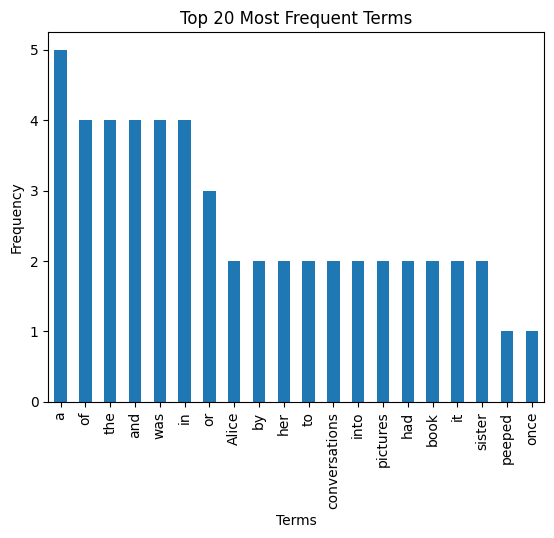

In [21]:
dtm = DTM()
dtm(doc_tokens, labels)

# Get the first 20 rows of the DTM as a DataFrame sorted by sum
df = dtm.to_df(sum=True, by="Total", ascending=False)[0:20]

# Plot the DataFrame
df.Total.plot(
    kind="bar",
    title="Top 20 Most Frequent Terms",
    xlabel="Terms",
    ylabel="Frequency"
)

We can even use Lexos' own `cloud` module to generate a word cloud of the most frequent terms in our corpus. In this visualization, each word's size is proportional to its overall frequency in the corpus—the larger the word appears, the more often it occurs.

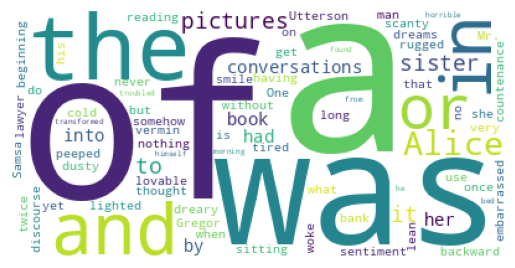

In [24]:
from lexos.visualization.cloud import wordcloud

wordcloud(dtm)

## Workflow

As a final example, let's load a larger dataset consisting of 11 literary texts aquired from the [Project Gutenberg](https://www.gutenberg.org/) website, and saved locally in our `txt_files` directory. Tokenizing novels can take a lot of time, so we will just work with  5000 characters (starting at 2000 to avoid Project Gutenberg headers).

In [ ]:
# Import the Loader class
from lexos.io.loader import Loader

# We loaded the Tokenizer class above, but this is in case you are skipping ahead and need to import it again
from lexos.tokenizer import Tokenizer

# Load the files
loader = Loader()
loader.load(["txt_files"])

# Get labels for each text
labels = loader.names

# Limit each text to first characters 2000 to 7000
# This is to avoid memory issues with very large texts
texts = [text[2000:7000] for text in loader.texts]

# Tokenize the documents - this may take a while
tokenizer = Tokenizer(model="en_core_web_sm")
docs = list(tokenizer.make_docs(texts))

Now we'll make the DTM. Notice that, since spaCy docs are iterable, they can be treated just like lists of tokens. In other words, you can submit a list of spaCy docs to the `DTM` class. But the results may not be what you want.

In [30]:
dtm = DTM()
dtm(docs, labels)
dtm.to_df(sum=True, by="Total", ascending=False).head(10)

,Metamorphosis by Franz Kafka,The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson,Alices Adventures in Wonderland by Lewis Carroll,Dracula by Bram Stoker,Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche,Pride and Prejudice by Jane Austen,The Adventures of Sherlock Holmes by Arthur Conan Doyle,The Great Gatsby by F. Scott Fitzgerald,"Frankenstein, Or, The Modern Prometheus",Romeo and Juliet by William Shakespeare,The Picture of Dorian Gray by Oscar Wilde,Total
\n,71,69,68,73,39,63,64,66,68,99,65,745
",",51,62,77,52,28,65,74,56,47,92,63,667
.,35,30,23,49,137,21,39,32,30,132,44,572
the,39,60,34,62,43,62,38,49,52,30,64,533
of,17,33,16,31,37,35,33,27,29,24,45,327
and,18,36,24,20,13,39,33,23,29,18,24,277
to,31,22,39,18,10,16,22,22,27,27,17,251
I,16,6,20,30,3,7,29,38,31,26,12,218
a,14,30,22,11,13,11,25,33,23,8,12,202
in,9,18,12,18,13,16,17,17,17,8,15,160


OK, there are some definite problems here. For one thing, our labels are pretty unwieldy. We should probably create shorter versions, such as using the author's name.

We can also see lots of "junk" in our terms list. This includes spaces, line breaks, punctuation marks, and probably digits. Looking at the most frequently occurring words, we can see that they are all typical stop words. Let's clean up the data to remove these unwanted items.

In [31]:
# Rename the labels for clarity
labels = ["Kafka", "Stevenson", "Carroll", "Stoker", "Nietzsche", "Austen", "Doyle", "Fitzgerald", "Shelley", "Shakespeare", "Wilde"]

# Clean the docs
cleaned_docs = []
for doc in docs:
    tokens = [token.text for token in doc if not (token.is_space or token.is_punct or token.is_digit or token.is_stop)]
    cleaned_docs.append(tokens)

dtm = DTM()
dtm(cleaned_docs, labels)
dtm.to_df(sum=True, by="Total", ascending=False).head(10)

,Kafka,Stevenson,Carroll,Stoker,Nietzsche,Austen,Doyle,Fitzgerald,Shelley,Shakespeare,Wilde,Total
man,1,6,0,0,3,0,1,4,1,3,3,22
time,4,1,7,3,0,1,2,0,2,0,1,21
SAMPSON,0,0,0,0,0,0,0,0,0,21,0,21
like,3,6,4,0,0,1,0,3,0,0,2,19
men,0,2,0,0,3,1,1,3,0,5,3,18
little,2,1,1,3,0,1,3,2,2,0,1,16
GREGORY,0,0,0,0,0,0,0,0,0,16,0,16
think,2,0,9,0,0,1,2,0,0,0,2,16
CHAPTER,0,0,0,15,0,0,0,0,0,0,1,16
way,0,5,4,1,0,1,1,1,0,0,2,15


Now that's more like it. It generally pays to create token lists for each document. And this technique also allows you to use ngrams. For instance, here is how we might make a DTM of bigrams. We'll only display the first eight documents so that the DataFrame is not too wide for the screen.

In [ ]:
# Import the Ngrams class for creating n-grams
from lexos.tokenizer.ngrams import Ngrams

# Create n-grams from the our documents
ng = Ngrams()
ngrams = ng.from_docs(docs=docs)

# Convert the n-grams to lists of tokens
ngrams = [list(doc) for doc in ngrams]

# Generate a DTM using the n-grams
dtm = DTM()
dtm(ngrams[0:8], labels[0:8])
dtm.to_df(sum=True, by="Total", ascending=False).head(10)


,Kafka,Stevenson,Carroll,Stoker,Nietzsche,Austen,Doyle,Fitzgerald,Total
of the,1,5,7,7,7,9,9,7,52
in the,0,2,3,9,4,5,2,5,30
on the,2,8,0,2,0,0,3,3,18
it was,2,4,5,2,1,1,1,1,17
and the,2,3,1,2,2,4,2,1,17
I had,0,0,0,8,1,0,3,4,16
to be,1,3,2,2,3,1,1,1,14
in a,0,3,3,0,1,1,4,2,14
of his,1,1,0,0,3,0,8,1,14
at the,4,3,2,1,0,1,0,3,14


## Applications and Experimentation

By building and analyzing a Document-Term Matrix (DTM), you unlock a wide range of real-world applications in text analysis and natural language processing. Here are some practical ways to apply these techniques:

- **Text Classification:** Use the DTM as input features for machine learning models to classify documents by topic, sentiment, or author.
- **Topic Modeling:** Identify underlying themes in large corpora by applying algorithms like Latent Dirichlet Allocation (LDA) to the DTM.
- **Authorship Attribution:** Compare term usage patterns across documents to attribute anonymous texts to likely authors.
- **Plagiarism Detection:** Measure document similarity using DTM-based metrics to detect copied or closely paraphrased content.
- **Trend Analysis:** Track the frequency of specific terms or topics over time to analyze trends in news, literature, or social media.
- **Keyword Extraction:** Identify the most distinctive or frequent terms in a set of documents for summarization or search optimization.
- **Corpus Exploration:** Visualize and explore large text collections to uncover patterns, outliers, or clusters of related documents.

Some examples are provided below. Note that these are all simple implementations, not recommended for real research. In many cases, Lexos offers its own more complete implementations.

In [57]:
# Create a DTM from the cleaned documents used above
dtm = DTM()
dtm(cleaned_docs, labels)

### Simple Text Classification Using Term Frequencies

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# For demonstration, let's assign a dummy author label to each document
authors = [
    "Carroll", "Stoker", "Shelley", "Kafka", "Austen", "Shakespeare",
    "Doyle", "Fitzgerald", "Wilde", "Stevenson", "Nietzsche"
]

# If there are more documents, extend or repeat author labels as needed
y = authors[:len(labels)]

# Convert the DTM to a NumPy array for machine learning
X = dtm.doc_term_matrix.toarray()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Multinomial Naive Bayes classifier
clf = MultinomialNB().fit(X_train, y_train)

# Print the accuracy of the classifier
print("Text Classification accuracy:", clf.score(X_test, y_test))

Text Classification accuracy: 0.0


### Topic Modeling (LDA)

In [43]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)
for idx, topic in enumerate(lda.components_):
    top_terms = [dtm.sorted_terms_list[i] for i in topic.argsort()[-5:][::-1]]
    print(f"Topic {idx + 1} top terms:", top_terms)


Topic 1 top terms: ['Ones', 'Noon', 'past', 'doubt', 'downgoing']
Topic 2 top terms: ['completely', 'united', 'bags', 'agitation', 'ugly']


### Authorship Attribution (Find the Most Likely Author of a Text)

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np
# from sklearn.cluster import KMeans

test_text = tokenizer.make_doc("It was a bright cold day in April, and the clocks were striking thirteen.")
test_doc = tokenizer.make_doc(" ".join([
    token.text for token in test_text
    if not (token.is_space or token.is_punct or token.is_stop)
]))
test_vec = dtm.vectorizer.transform([test_doc])
predicted_author = clf.predict(test_vec.toarray())[0]
print("Predicted author for test text:", predicted_author)

Predicted author for test text: Austen


### Similarity between Documents

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_matrix = cosine_similarity(X)
np.fill_diagonal(similarity_matrix, 0)
most_similar = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
print(f"Most similar documents: {labels[most_similar[0]]} and {labels[most_similar[1]]} (similarity={similarity_matrix[most_similar]:.2f})")

Most similar documents: Kafka and Carroll (similarity=0.22)


### Trend Analysis (track frequency of a term across documents)

In [48]:
term = "said"
if term in dtm.sorted_terms_list:
    idx = dtm.sorted_terms_list.index(term)
    term_freqs = X[:, idx]
    for label, freq in zip(labels, term_freqs):
        print(f"Frequency of '{term}' in '{label}': {freq}")
else:
    print(f"Term '{term}' not found in vocabulary.")

Frequency of 'said' in 'Kafka': 0
Frequency of 'said' in 'Stevenson': 0
Frequency of 'said' in 'Carroll': 0
Frequency of 'said' in 'Stoker': 0
Frequency of 'said' in 'Nietzsche': 0
Frequency of 'said' in 'Austen': 0
Frequency of 'said' in 'Doyle': 0
Frequency of 'said' in 'Fitzgerald': 0
Frequency of 'said' in 'Shelley': 0
Frequency of 'said' in 'Shakespeare': 1
Frequency of 'said' in 'Wilde': 0


### Keyword Extraction (top terms in a document)

In [ ]:
doc_idx = 0
top_terms_idx = X[doc_idx].argsort()[-5:][::-1]
top_terms = [dtm.sorted_terms_list[i] for i in top_terms_idx]
print(f"Top terms in '{labels[doc_idx]}':", top_terms)

Top terms in 'Kafka': ['elevates', 'intended', 'vague', 'begin', 'slouched']


### Corpus Exploration (cluster documents by similarity)

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
clusters = [i + 1 for i in kmeans.labels_]
for i, label in enumerate(labels):
    print(f"Document '{label}' assigned to cluster {clusters[i]}")

Document 'Kafka' assigned to cluster 3
Document 'Stevenson' assigned to cluster 3
Document 'Carroll' assigned to cluster 3
Document 'Stoker' assigned to cluster 3
Document 'Nietzsche' assigned to cluster 1
Document 'Austen' assigned to cluster 1
Document 'Doyle' assigned to cluster 3
Document 'Fitzgerald' assigned to cluster 1
Document 'Shelley' assigned to cluster 1
Document 'Shakespeare' assigned to cluster 2
Document 'Wilde' assigned to cluster 1
